In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,PowerTransformer,StandardScaler,PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer,KNNImputer,IterativeImputer
from tensorflow import keras
from keras.models import load_model
from keras.layers import Dense,BatchNormalization, Dropout
from keras import Sequential
from keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam


import joblib


In [27]:
df=pd.read_csv('car_price_dataset.csv')

In [4]:
df.head()

,Brand,Model,Year,CarAge,Condition,Mileage(km),EngineSize(L),FuelType,Horsepower,Torque,...,Color,Interior,Options,City,AccidentHistory,Insurance,RegistrationStatus,FuelEfficiency(L/100km),PricePerKm,Price($)
0,Porsche,Panamera,2008,17,Used,256395,3.3,Gasoline,513,395,...,White,Cloth,"Navigation, Cruise Control, Heated Seats, Blue...",Tehran,No,Valid,Incomplete,11.96,0.05,13884
1,Audi,A6,2023,2,Used,20433,2.2,Diesel,302,270,...,Black,Cloth,"Parking Sensors, Cruise Control, Touchscreen",Berlin,Yes,Expired,Incomplete,8.74,1.90,38888
2,BMW,X5,2022,3,Used,52328,3.2,Gasoline,400,388,...,Gray,Leather,"Touchscreen, Bluetooth, Cruise Control, Naviga...",Tokyo,Yes,Valid,Complete,15.68,0.63,33074
3,Hyundai,Tucson,2019,6,Used,91878,1.6,Hybrid,187,219,...,Silver,Cloth,"Sunroof, Rear Camera, Bluetooth, Parking Senso...",Delhi,No,Expired,Complete,9.45,0.14,12966
4,Fiat,500,2012,13,Damaged,192331,1.1,Gasoline,90,112,...,Red,Leather,"Heated Seats, Touchscreen",Delhi,No,Valid,Complete,7.16,0.01,2670


In [5]:
df.tail()

,Brand,Model,Year,CarAge,Condition,Mileage(km),EngineSize(L),FuelType,Horsepower,Torque,...,Color,Interior,Options,City,AccidentHistory,Insurance,RegistrationStatus,FuelEfficiency(L/100km),PricePerKm,Price($)
49995,Ford,Mustang,2022,3,Used,50900,5.0,Gasoline,388,601,...,Black,Leather,"Parking Sensors, Heated Seats, Navigation",Berlin,No,Expired,Complete,17.47,0.38,19504
49996,Volkswagen,Tiguan,2019,6,Used,90071,2.0,Gasoline,184,257,...,Gray,Cloth,"Parking Sensors, Cruise Control, Touchscreen",Dubai,No,Valid,Complete,11.46,0.16,14661
49997,Mercedes-Benz,S-Class,2016,9,Used,137994,3.4,Gasoline,514,415,...,Gray,Leather,"Navigation, Cruise Control, Parking Sensors, R...",Berlin,No,Valid,Complete,12.09,0.31,42466
49998,Audi,A4,2023,2,Damaged,29747,2.0,Gasoline,246,286,...,Black,Leather,"Rear Camera, Navigation",Paris,Yes,Expired,Incomplete,9.36,0.50,14926
49999,Audi,Q7,2009,16,Used,245792,2.7,Gasoline,319,330,...,Red,Cloth,"Rear Camera, Heated Seats, Cruise Control",Cape Town,Yes,Expired,Complete,13.32,0.03,7411


In [6]:
df.sample(40)

,Brand,Model,Year,CarAge,Condition,Mileage(km),EngineSize(L),FuelType,Horsepower,Torque,...,Color,Interior,Options,City,AccidentHistory,Insurance,RegistrationStatus,FuelEfficiency(L/100km),PricePerKm,Price($)
32806,Kia,Sportage,2012,13,Used,197490,2.0,Gasoline,227,234,...,White,Leather,"Navigation, Touchscreen, Cruise Control",Sao Paulo,No,Expired,Incomplete,11.19,0.03,5529
19974,Honda,Accord,2024,1,Used,19342,1.7,Gasoline,246,251,...,Gray,Leather,"Rear Camera, Heated Seats, Parking Sensors, Bl...",Toronto,No,Valid,Incomplete,8.59,1.20,23306
9094,BMW,3 Series,2012,13,Used,196584,2.3,Gasoline,319,278,...,Gray,Cloth,"Navigation, Rear Camera",Toronto,No,Expired,Incomplete,9.46,0.04,8706
49248,Hyundai,i10,2005,20,Used,301861,1.2,Gasoline,79,139,...,White,Cloth,"Rear Camera, Cruise Control",Berlin,No,Valid,Complete,7.00,0.01,1571
20717,Toyota,Corolla,2016,9,Damaged,138387,1.9,Hybrid,165,228,...,Blue,Leather,"Heated Seats, Navigation, Sunroof",Tokyo,No,Expired,Complete,7.90,0.03,4027
34296,Mazda,MX-5 Miata,2006,19,Used,281183,2.0,Gasoline,181,284,...,Blue,Leather,"Parking Sensors, Navigation, Touchscreen, Sunroof",Cape Town,No,Valid,Incomplete,9.43,0.01,3247
12646,BMW,7 Series,2025,0,New,321,3.9,Hybrid,463,490,...,Blue,Leather,Rear Camera,Paris,No,Valid,Complete,13.55,NaN,103226
17311,Porsche,911 Carrera,2025,0,New,454,3.5,Gasoline,518,443,...,Silver,Cloth,"Heated Seats, Parking Sensors",Paris,No,Valid,Complete,12.76,NaN,100630
48754,Mazda,Mazda3,2017,8,Used,119773,2.4,Gasoline,175,358,...,Red,Cloth,"Heated Seats, Parking Sensors, Touchscreen, Na...",Toronto,No,Expired,Incomplete,10.04,0.08,9693
35893,Audi,A6,2017,8,Used,127518,2.9,Diesel,288,302,...,Red,Cloth,Touchscreen,Tokyo,No,Expired,Incomplete,12.01,0.19,24098


In [7]:
df.nunique()

,0
Brand,17
Model,43
Year,21
CarAge,21
Condition,3
Mileage(km),44835
EngineSize(L),53
FuelType,4
Horsepower,623
Torque,744


In [8]:
num_col=list(df.select_dtypes(include=['int64','float64']).columns)
cat_col=list(df.select_dtypes(include=['object','category']).columns)
target='Price($)'



In [9]:
num_col.remove('Price($)')
num_col.remove('PricePerKm')

In [65]:
num_col

['Year',
 'CarAge',
 'Mileage(km)',
 'EngineSize(L)',
 'Horsepower',
 'Torque',
 'Doors',
 'Seats',
 'FuelEfficiency(L/100km)']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Brand                    50000 non-null  object 
 1   Model                    50000 non-null  object 
 2   Year                     50000 non-null  int64  
 3   CarAge                   50000 non-null  int64  
 4   Condition                50000 non-null  object 
 5   Mileage(km)              50000 non-null  int64  
 6   EngineSize(L)            50000 non-null  float64
 7   FuelType                 50000 non-null  object 
 8   Horsepower               50000 non-null  int64  
 9   Torque                   50000 non-null  int64  
 10  Transmission             50000 non-null  object 
 11  DriveType                50000 non-null  object 
 12  BodyType                 50000 non-null  object 
 13  Doors                    50000 non-null  int64  
 14  Seats                 

In [12]:
df.describe()

,Year,CarAge,Mileage(km),EngineSize(L),Horsepower,Torque,Doors,Seats,FuelEfficiency(L/100km),PricePerKm,Price($)
count,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,47541.000000,50000.000000
mean,2014.99852,10.00148,150048.081460,2.127286,279.731440,326.660080,4.139060,4.721720,9.346222,0.305946,15780.750960
std,6.06553,6.06553,91085.992898,1.139203,153.703605,137.000291,0.979276,1.080418,4.072040,0.855643,16838.548646
min,2005.00000,0.00000,0.000000,0.000000,65.000000,16.000000,2.000000,2.000000,0.000000,0.000000,1249.000000
25%,2010.00000,5.00000,71548.000000,1.400000,179.000000,227.000000,4.000000,5.000000,7.530000,0.020000,4943.000000
50%,2015.00000,10.00000,150478.000000,2.000000,240.000000,307.000000,4.000000,5.000000,9.680000,0.060000,10063.000000
75%,2020.00000,15.00000,228461.500000,2.800000,386.000000,415.000000,5.000000,5.000000,11.980000,0.220000,19745.250000
max,2025.00000,20.00000,320262.000000,6.000000,905.000000,850.000000,5.000000,7.000000,21.180000,34.560000,131850.000000


In [13]:
df.isnull().sum()

,0
Brand,0
Model,0
Year,0
CarAge,0
Condition,0
Mileage(km),0
EngineSize(L),0
FuelType,0
Horsepower,0
Torque,0


In [14]:
df.duplicated().sum()

np.int64(0)

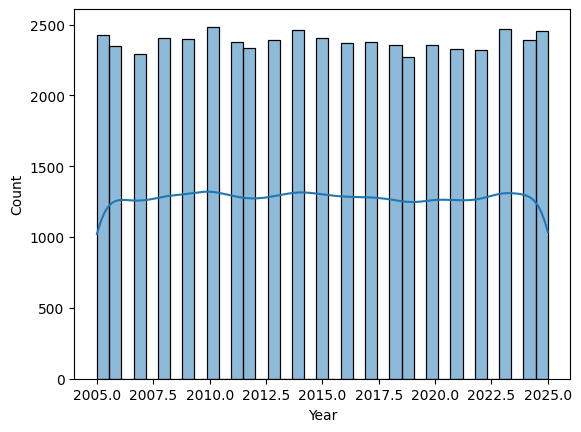

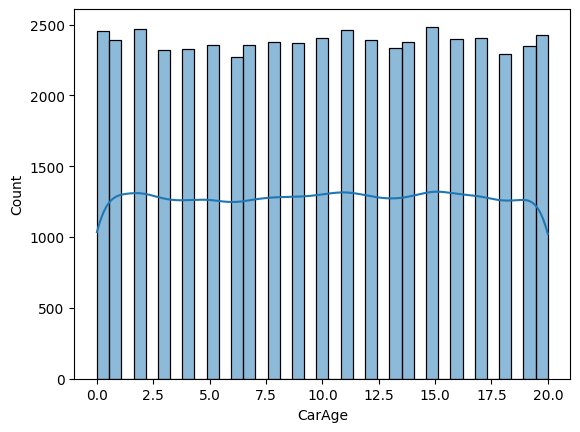

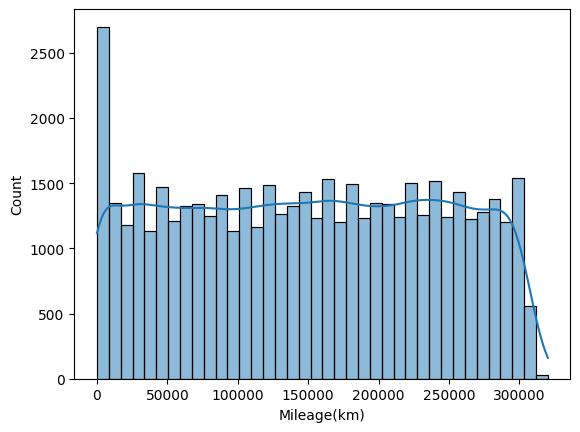

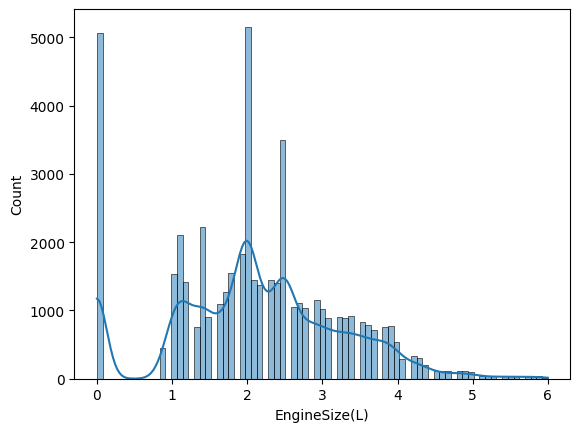

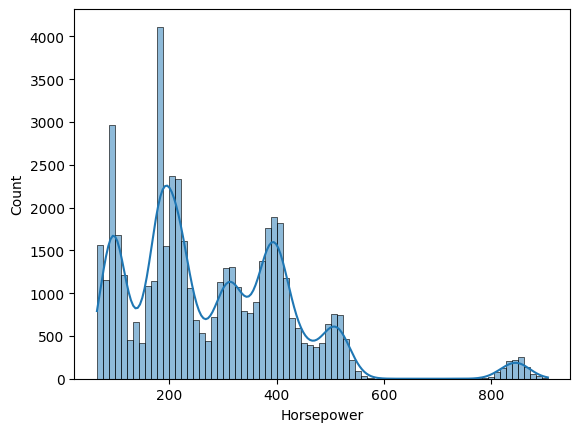

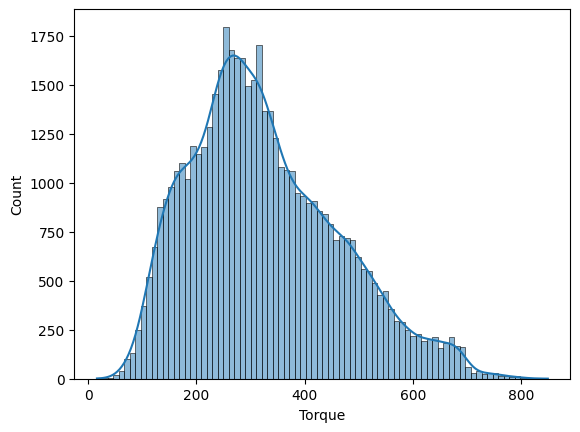

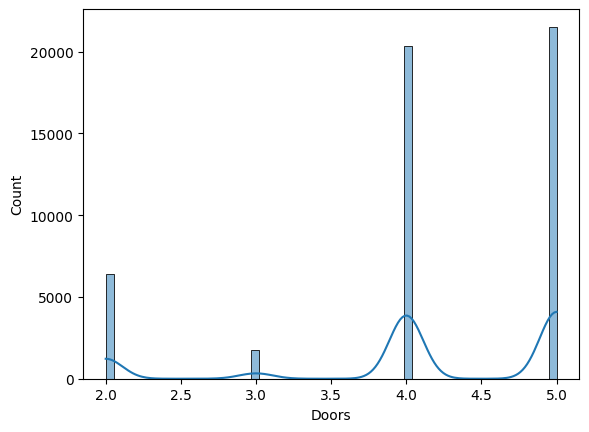

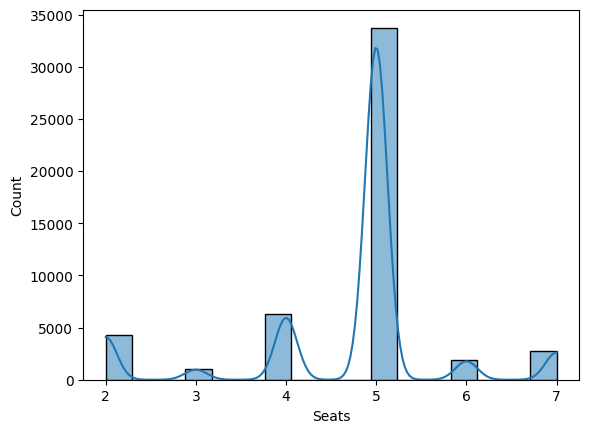

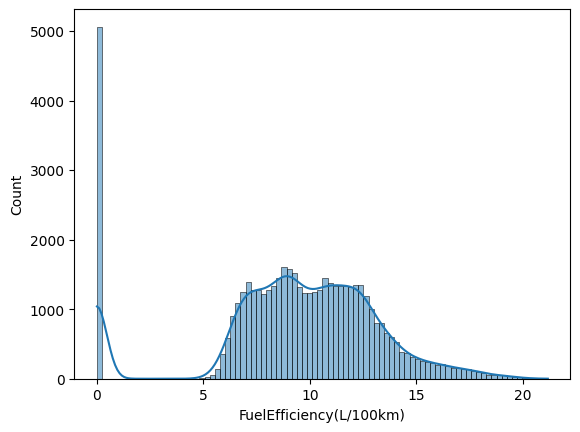

In [16]:
for i in num_col:
  sns.histplot(df[i],kde=True)

  plt.show()

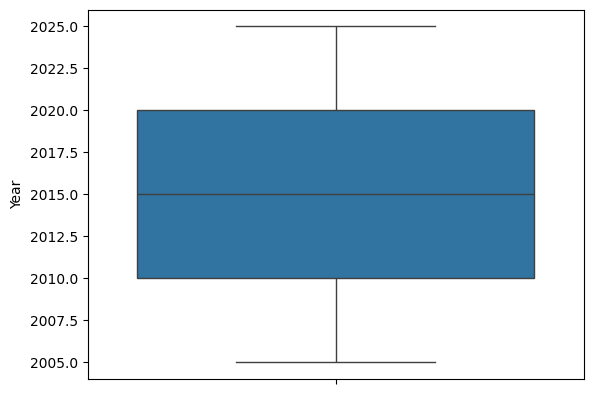

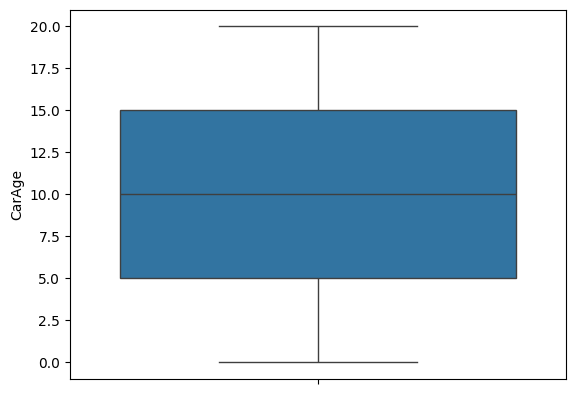

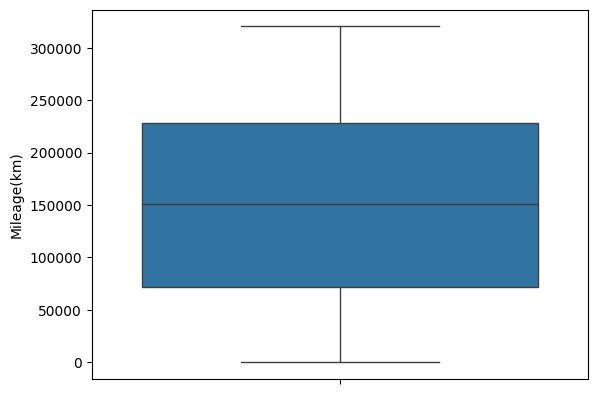

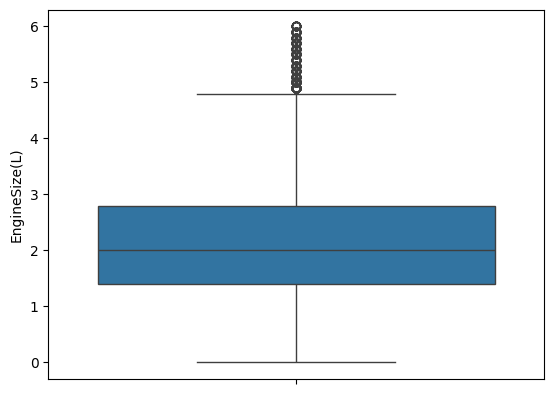

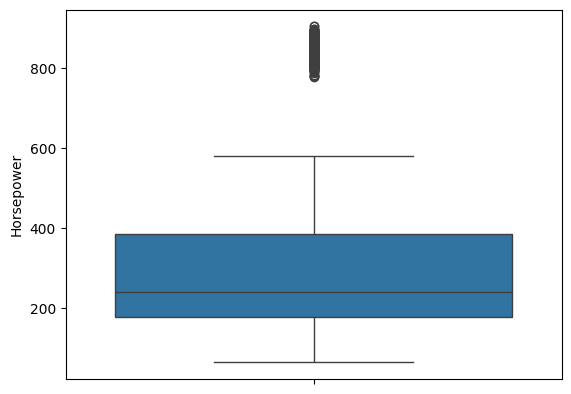

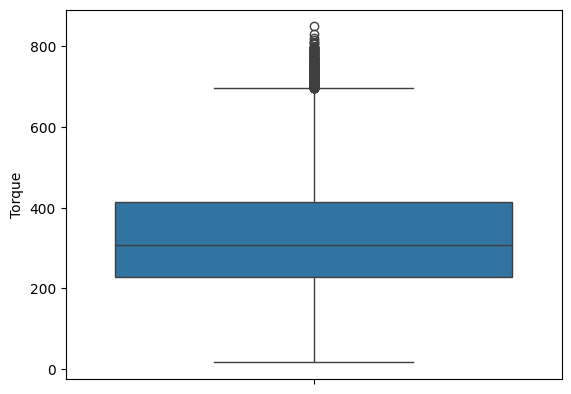

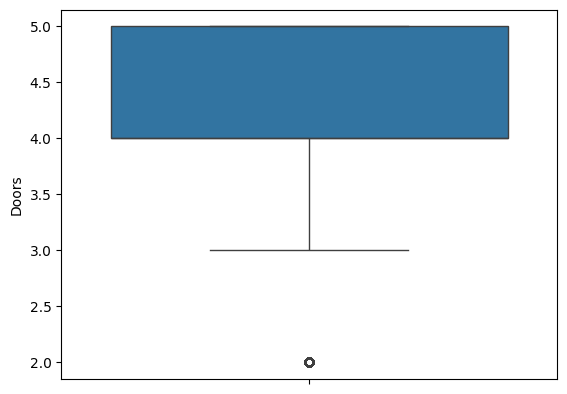

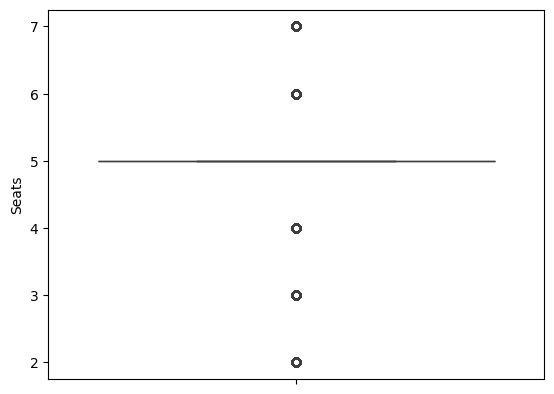

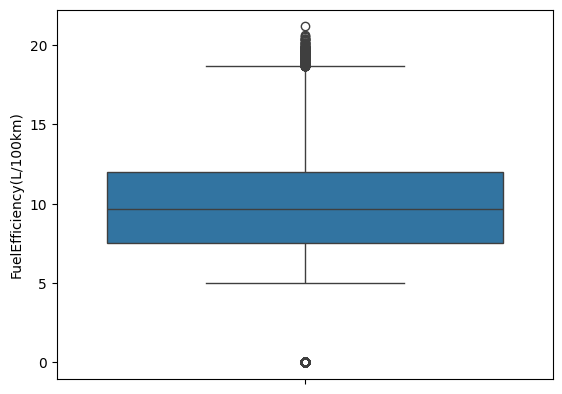

In [17]:
for i in num_col:

  sns.boxplot(df[i])
  plt.show()

  plt.show()

In [21]:

for i in num_col:
 Q1 = df[i].quantile(0.25)
 Q3 = df[i].quantile(0.75)

 IQR = Q3 - Q1

 lower = Q1 - 1.5 * IQR
 upper = Q3 + 1.5 * IQR

 outliers = df[(df[i] < lower) | (df[i] > upper)]

 print(f"Number of outliers {i} :", len(outliers))

Number of outliers Year : 0
Number of outliers CarAge : 0
Number of outliers Mileage(km) : 0
Number of outliers EngineSize(L) : 577
Number of outliers Horsepower : 1137
Number of outliers Torque : 268
Number of outliers Doors : 6418
Number of outliers Seats : 16252
Number of outliers FuelEfficiency(L/100km) : 5281


In [23]:
df.skew(numeric_only=True)

,0
Year,0.007895
CarAge,-0.007895
Mileage(km),-0.005697
EngineSize(L),0.084571
Horsepower,1.116120
Torque,0.589296
Doors,-1.100951
Seats,-0.912788
FuelEfficiency(L/100km),-0.736255
PricePerKm,9.515996


In [29]:
pf=PowerTransformer()
df[['Horsepower']]=pf.fit_transform(df[['Horsepower']])
df[['Doors']]=pf.fit_transform(df[['Doors']])
df[['Seats']]=pf.fit_transform(df[['Seats']])
df[['FuelEfficiency(L/100km)']]=pf.fit_transform(df[['FuelEfficiency(L/100km)']])

In [30]:
df.skew(numeric_only=True)

,0
Year,0.007895
CarAge,-0.007895
Mileage(km),-0.005697
EngineSize(L),0.084571
Horsepower,-0.025337
Torque,0.589296
Doors,-0.352079
Seats,0.144721
FuelEfficiency(L/100km),-0.261892
PricePerKm,9.515996


In [63]:
df.drop('PricePerKm',axis=1,inplace=True)

KeyError: "['PricePerKm'] not found in axis"

In [64]:
df

,Brand,Model,Year,CarAge,Condition,Mileage(km),EngineSize(L),FuelType,Horsepower,Torque,...,Seats,Color,Interior,Options,City,AccidentHistory,Insurance,RegistrationStatus,FuelEfficiency(L/100km),Price($)
0,Porsche,Panamera,2008,17,Used,256395,3.3,Gasoline,1.390126,395,...,-0.781512,White,Cloth,"Navigation, Cruise Control, Heated Seats, Blue...",Tehran,No,Valid,Incomplete,0.640714,13884
1,Audi,A6,2023,2,Used,20433,2.2,Diesel,0.348155,270,...,0.176033,Black,Cloth,"Parking Sensors, Cruise Control, Touchscreen",Berlin,Yes,Expired,Incomplete,-0.230089,38888
2,BMW,X5,2022,3,Used,52328,3.2,Gasoline,0.884464,388,...,2.660547,Gray,Leather,"Touchscreen, Bluetooth, Cruise Control, Naviga...",Tokyo,Yes,Valid,Complete,1.727044,33074
3,Hyundai,Tucson,2019,6,Used,91878,1.6,Hybrid,-0.487529,219,...,0.176033,Silver,Cloth,"Sunroof, Rear Camera, Bluetooth, Parking Senso...",Delhi,No,Expired,Complete,-0.044317,12966
4,Fiat,500,2012,13,Damaged,192331,1.1,Gasoline,-1.590708,112,...,-0.781512,Red,Leather,"Heated Seats, Touchscreen",Delhi,No,Valid,Complete,-0.629353,2670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Ford,Mustang,2022,3,Used,50900,5.0,Gasoline,0.824590,601,...,-0.781512,Black,Leather,"Parking Sensors, Heated Seats, Navigation",Berlin,No,Expired,Complete,2.276262,19504
49996,Volkswagen,Tiguan,2019,6,Used,90071,2.0,Gasoline,-0.514089,257,...,1.322614,Gray,Cloth,"Parking Sensors, Cruise Control, Touchscreen",Dubai,No,Valid,Complete,0.500932,14661
49997,Mercedes-Benz,S-Class,2016,9,Used,137994,3.4,Gasoline,1.394203,415,...,0.176033,Gray,Leather,"Navigation, Cruise Control, Parking Sensors, R...",Berlin,No,Valid,Complete,0.677314,42466
49998,Audi,A4,2023,2,Damaged,29747,2.0,Gasoline,-0.021173,286,...,0.176033,Black,Leather,"Rear Camera, Navigation",Paris,Yes,Expired,Incomplete,-0.068072,14926


In [33]:
X=df.iloc[:,0:-1]
Y=df.iloc[:,-1]

In [38]:
X

,Brand,Model,Year,CarAge,Condition,Mileage(km),EngineSize(L),FuelType,Horsepower,Torque,...,Doors,Seats,Color,Interior,Options,City,AccidentHistory,Insurance,RegistrationStatus,FuelEfficiency(L/100km)
0,Porsche,Panamera,2008,17,Used,256395,3.3,Gasoline,1.390126,395,...,-0.423639,-0.781512,White,Cloth,"Navigation, Cruise Control, Heated Seats, Blue...",Tehran,No,Valid,Incomplete,0.640714
1,Audi,A6,2023,2,Used,20433,2.2,Diesel,0.348155,270,...,-0.423639,0.176033,Black,Cloth,"Parking Sensors, Cruise Control, Touchscreen",Berlin,Yes,Expired,Incomplete,-0.230089
2,BMW,X5,2022,3,Used,52328,3.2,Gasoline,0.884464,388,...,1.035974,2.660547,Gray,Leather,"Touchscreen, Bluetooth, Cruise Control, Naviga...",Tokyo,Yes,Valid,Complete,1.727044
3,Hyundai,Tucson,2019,6,Used,91878,1.6,Hybrid,-0.487529,219,...,1.035974,0.176033,Silver,Cloth,"Sunroof, Rear Camera, Bluetooth, Parking Senso...",Delhi,No,Expired,Complete,-0.044317
4,Fiat,500,2012,13,Damaged,192331,1.1,Gasoline,-1.590708,112,...,-1.306989,-0.781512,Red,Leather,"Heated Seats, Touchscreen",Delhi,No,Valid,Complete,-0.629353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Ford,Mustang,2022,3,Used,50900,5.0,Gasoline,0.824590,601,...,-1.778818,-0.781512,Black,Leather,"Parking Sensors, Heated Seats, Navigation",Berlin,No,Expired,Complete,2.276262
49996,Volkswagen,Tiguan,2019,6,Used,90071,2.0,Gasoline,-0.514089,257,...,1.035974,1.322614,Gray,Cloth,"Parking Sensors, Cruise Control, Touchscreen",Dubai,No,Valid,Complete,0.500932
49997,Mercedes-Benz,S-Class,2016,9,Used,137994,3.4,Gasoline,1.394203,415,...,-0.423639,0.176033,Gray,Leather,"Navigation, Cruise Control, Parking Sensors, R...",Berlin,No,Valid,Complete,0.677314
49998,Audi,A4,2023,2,Damaged,29747,2.0,Gasoline,-0.021173,286,...,-0.423639,0.176033,Black,Leather,"Rear Camera, Navigation",Paris,Yes,Expired,Incomplete,-0.068072


In [37]:
Y

,Price($)
0,13884
1,38888
2,33074
3,12966
4,2670
...,...
49995,19504
49996,14661
49997,42466
49998,14926


In [40]:
X_train, X_temp, y_train, y_temp = train_test_split(X,Y,test_size=0.2,random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,test_size=0.5,random_state=42)

In [41]:
df.isnull().sum()

,0
Brand,0
Model,0
Year,0
CarAge,0
Condition,0
Mileage(km),0
EngineSize(L),0
FuelType,0
Horsepower,0
Torque,0


In [42]:
X_train.shape, X_temp.shape, X_val.shape, y_test.shape

((40000, 23), (10000, 23), (5000, 23), (5000,))

In [43]:
preprocessor = ColumnTransformer(transformers = [
    ('num', StandardScaler(), num_col),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col)
])

In [44]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Year', 'CarAge', 'Mileage(km)',
                                  'EngineSize(L)', 'Horsepower', 'Torque',
                                  'Doors', 'Seats',
                                  'FuelEfficiency(L/100km)']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Brand', 'Model', 'Condition', 'FuelType',
                                  'Transmission', 'DriveType', 'BodyType',
                                  'Color', 'Interior', 'Options', 'City',
                                  'AccidentHistory', 'Insurance',
                                  'RegistrationStatus'])])

In [45]:
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [46]:
X_train_processed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 920000 stored elements and shape (40000, 6872)>

In [48]:

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],),
                 kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(1, activation='linear'))

In [49]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       879,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 888,833 (3.39 MB)

 Trainable params: 888,449 (3.39 MB)

 Non-trainable params: 384 (1.50 KB)

In [53]:
callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=10,
    verbose=1,
    mode='min',
    restore_best_weights=True,
    start_from_epoch=5
)

In [54]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
   loss='mse',
    metrics=['mae']
)

In [55]:
history = model.fit(X_train_processed, y_train, epochs=100, batch_size=32, validation_data=(X_val_processed,y_val), callbacks=[callback])

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 22183814.0000 - mae: 3143.7671 - val_loss: 4484211.0000 - val_mae: 1157.6345
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 20653566.0000 - mae: 3086.1743 - val_loss: 5075917.5000 - val_mae: 1205.9904
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 22647370.0000 - mae: 3191.8645 - val_loss: 7271294.5000 - val_mae: 1562.9008
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 21147432.0000 - mae: 3110.3608 - val_loss: 5987092.0000 - val_mae: 1679.2714
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 22465946.0000 - mae: 3198.1523 - val_loss: 5820504.0000 - val_mae: 1293.8779
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 22042196.0000 - mae: 3181.4287 - val_loss: 4572192.0000 - val_mae: 1234.8101
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 21697292.0000 - mae: 3188.8647 - val_loss: 6769693.0000 - val_mae: 1523.2832
Epoch 8/100
1250/12

In [56]:
loss, mae = model.evaluate(X_val_processed, y_val)

print('Val MAE:', mae)
print('Val Loss:', loss)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4572192.0000 - mae: 1234.8101
Val MAE: 1234.81005859375
Val Loss: 4572192.0


In [57]:
y_pred = model.predict(X_test_processed).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
MAE: 1217.122802734375
MSE: 4719691.5
RMSE: 2172.485097762468
R² Score: 0.983141303062439


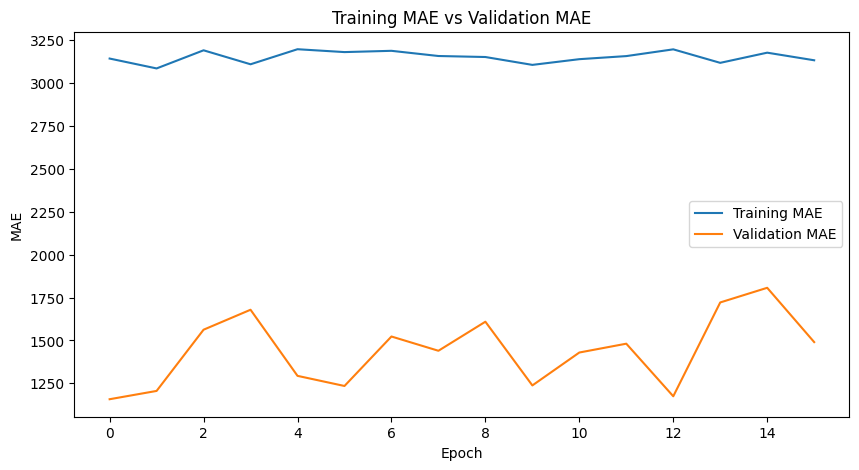

In [58]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title('Training MAE vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.show()

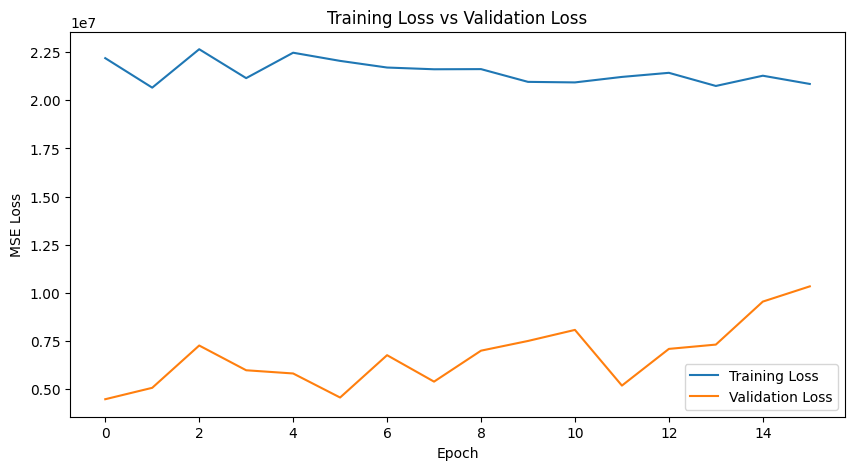

In [59]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

plt.show()

In [60]:
train_loss, train_mae = model.evaluate(X_train_processed, y_train)

print("Training MAE:", train_mae)
print("Training Loss:", train_loss)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 4386228.5000 - mae: 1127.9991
Training MAE: 1127.9991455078125
Training Loss: 4386228.5


In [61]:
model.save('model.keras')

In [62]:
joblib.dump(preprocessor, 'ColumnTransformer.pkl')
print('column Transformer save successfuly')

column Transformer save successfuly
